## TSB-AD Quick Start

### Run AD Model

In this tutorial, we demonstrate how to (i) load a univariate or multivariate time series from the TSB-AD benchmark, (ii) run an unsupervised anomaly detector, and (iii) evaluate its detection quality using standard measures.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
import pandas as pd
from TSB_AD.model_wrapper import run_Unsupervise_AD, run_Semisupervise_AD
from TSB_AD.evaluation.metrics import get_metrics

# Specify data directory (single univariate/ multivariate file)
data_direc = './Datasets/TSB-AD-U/001_NAB_id_1_Facility_tr_1007_1st_2014.csv'

# Loading Data
df = pd.read_csv(data_direc).dropna()
data = df.iloc[:, 0:-1].values.astype(float)
label = df['Label'].astype(int).to_numpy()

print("Loaded data with shape:", data.shape)
print("Loaded labels with shape:", label.shape)

# =========================
# IForest (unsupervised)
# =========================
output_iforest = run_Unsupervise_AD('IForest', data)
metrics_iforest = get_metrics(output_iforest, label)
print("IForest evaluation:\n", metrics_iforest)

# =========================
# PCA (unsupervised)
# =========================
output_pca = run_Unsupervise_AD('PCA', data)
metrics_pca = get_metrics(output_pca, label)
print("PCA evaluation:\n", metrics_pca)

# =========================
# Custom_AD (pseudo semisupervised)
# =========================
# Use the same file split convention as other scripts: the third element
# from the end (before extension) encodes the train length
train_index = data_direc.split('/')[-1].split('.')[0].split('_')[-3]
train_index = int(train_index)

data_train = data[:train_index]
data_test = data

# Simple HP placeholder; adjust as needed inside your Custom_AD
custom_hp = {'HP': 'HP'}

output_custom = run_Semisupervise_AD('Custom_AD', data_train, data_test, HP=custom_hp['HP'])
metrics_custom = get_metrics(output_custom, label)
print("Custom_AD evaluation:\n", metrics_custom)

Loaded data with shape: (4031, 1)
Loaded labels with shape: (4031,)
IForest evaluation:
 {'AUC-PR': 0.15269855522128545, 'AUC-ROC': 0.6810639502159712, 'VUS-PR': 0.1847473477766243, 'VUS-ROC': 0.7528825596433526, 'Standard-F1': 0.26405951956918766, 'PA-F1': 0.8542963885429639, 'Event-based-F1': 0.37010676156583594, 'R-based-F1': 0.19703332769196885, 'Affiliation-F': 0.8232591781493652}
PCA evaluation:
 {'AUC-PR': 0.7956508501129314, 'AUC-ROC': 0.9059292449548768, 'VUS-PR': 0.8136138874982192, 'VUS-ROC': 0.9357317496173422, 'Standard-F1': 0.8284740249663477, 'PA-F1': 1.0, 'Event-based-F1': 0.9999999999999996, 'R-based-F1': 0.759779845496952, 'Affiliation-F': 0.996308430785461}
Custom_AD evaluation:
 {'AUC-PR': 0.08174942120312274, 'AUC-ROC': 0.4883587460394756, 'VUS-PR': 0.10561667861272184, 'VUS-ROC': 0.574171264257874, 'Standard-F1': 0.15834372313213177, 'PA-F1': 0.9002624671916011, 'Event-based-F1': 0.17391304347826067, 'R-based-F1': 0.13944545589405666, 'Affiliation-F': 0.6782912284

In [37]:
output_custom[2500:2600]

array([0.13466515, 0.40075004, 0.23085402, 0.29772772, 0.64829524,
       0.72432588, 0.44996813, 0.87735102, 0.02220153, 0.36694994,
       0.301717  , 0.58748252, 0.0144726 , 0.47882747, 0.6681802 ,
       0.0457328 , 0.58890054, 0.71827625, 0.92726537, 0.75178296,
       0.37168027, 0.6201989 , 0.320945  , 0.36718383, 0.61740916,
       0.46550567, 0.44506041, 0.13040451, 0.05285378, 0.3581175 ,
       0.50109782, 0.63211486, 0.37148414, 0.26162285, 0.87166094,
       0.42061712, 0.91995423, 0.01729118, 0.92418181, 0.35600178,
       0.81353078, 0.37417323, 0.10390509, 0.48840195, 0.04951833,
       0.02091035, 0.52526667, 0.91386352, 0.41083531, 0.56575827,
       0.96821239, 0.65946385, 0.07398331, 0.61886645, 0.38252341,
       0.79015813, 0.62608416, 0.31865222, 0.32871472, 0.65193776,
       0.90303336, 0.67542079, 0.68710273, 0.98693014, 0.88289866,
       0.00544052, 0.17073799, 0.03653781, 0.25309047, 0.63182091,
       0.0856696 , 0.53542626, 0.46325192, 0.03706358, 0.67487

### Plot Time Series with Ground Truth Anomalies

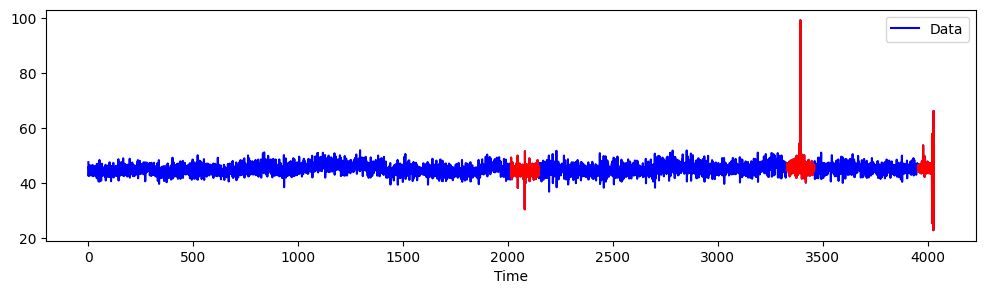

In [14]:
import matplotlib.pyplot as plt
from TSB_AD.evaluation.basic_metrics import basic_metricor

grader = basic_metricor()
range_anomaly = grader.range_convers_new(label)
fig, ax = plt.subplots(figsize=(12, 3))  # Adjust the figure size as needed
ax.plot(range(len(data)), data, color='blue', linewidth=1.5, label='Data')
for r in range_anomaly:
    if r[0] == r[1]:
        ax.plot(r[0], data[r[0]], 'ro', markersize=10)
    else:
        ax.plot(range(r[0], r[1] + 1), data[r[0]:r[1] + 1], color='red', linewidth=1.5) 
plt.legend()
plt.xlabel('Time')
plt.show()